# Workshop: Face Image Classification with CNNs

> **Important note about the labels**
> This dataset contains two face-image classes provided by the dataset creators. These labels are a simplification of a much more complex real-world concept. In this workshop, we treat the task as a **binary image classification exercise**, not as a reliable system for inferring gender identity from appearance.

## By the end of this workshop, you will be able to:
1. Load an image dataset and understand what a model actually "sees" (tensors, channels, pixel values)
2. Train a pretrained CNN classifier quickly using transfer learning
3. Build a small CNN from scratch and understand each component
4. Interpret model decisions visually using Grad-CAM

## Workshop agenda

| # | Section | Who | Time |
|---|---------|-----|------|
| 0 | Setup | run once | 3 min |
| 1 | The task — first look at the data | 🟢 everyone | 8 min |
| 2 | Transfer learning — quick win | 🟢🟡 everyone | 15 min |
| 3 | Build a CNN from scratch | 🟡 everyone | 20 min |
| 4 | Compare & interpret | 🟢🟡 everyone | 12 min |
| 5 | Extensions (optional) | 🔴 advanced | any |

**Look for 🟢 Beginner · 🟡 Intermediate · 🔴 Advanced labels on each task. The default path is 🟢 + 🟡 only.**

---

## How to use this notebook

> **Predict → Run → Reflect**
>
> Before every interactive cell:
> 1. **Predict** — write down what you expect
> 2. **Run** — execute the cell
> 3. **Reflect** — was your prediction right? Why or why not?


## 0. Setup

Run the next two cells once. If your environment already has everything installed, they will finish quickly.

> **⚠️ GPU required** — This notebook runs much faster on a GPU.
>
> In **Google Colab**: go to **Runtime → Change runtime type → T4 GPU → Save**, then re-run from the top.


In [1]:
%pip install -q opencv-python grad-cam ipywidgets tensorboard tqdm pandas requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 76.8 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 85.8 MB/s eta 0:00:00


In [2]:
import io
import json
import random
import shutil
from collections import Counter
from pathlib import Path

import cv2
import requests
import zipfile
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms
from torchvision.models import (
    mobilenet_v2, MobileNet_V2_Weights,
    resnet50, ResNet50_Weights,
    vit_b_16, ViT_B_16_Weights,
)
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running in Colab:", IN_COLAB)
print("Using device:", device)

if device == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")


Running in Colab: True
Using device: cuda


## 1. Workshop control panel

All tunable parameters live here. **You should not need to change any other cell** to run a different experiment — just update these values and re-run from this cell downwards.

> After changing any setting: **Runtime → Run after** (or Shift+Enter through each cell below).


In [3]:
# =========================
# Workshop control panel
# =========================

# --- Data ---
SEED               = 42
N_IMAGES_PER_CLASS = 250     # images randomly selected from each class (None = all)
VALIDATION_SPLIT   = 0.20    # fraction of training data held out for validation

# --- Shared training ---
BATCH_SIZE         = 32      # images per mini-batch (try 16, 64)
NUM_WORKERS        = 0       # keep 0 in Jupyter/Colab (avoids multiprocessing issues)

# --- Section 2: Transfer learning ---
IMG_SIZE_PRETRAINED = 144    # use 224 when MODEL_NAME = "vit_b_16"
EPOCHS_PRETRAINED   = 4
LR_PRETRAINED       = 1e-4
FREEZE_BACKBONE     = True
UNFREEZE_LAST_BLOCK = False
MODEL_NAME          = "mobilenet_v2"   # "mobilenet_v2" | "resnet50" | "vit_b_16"
DROPOUT_PRETRAINED  = 0.0
USE_DATA_AUGMENTATION = False

# --- Section 3: Handcrafted CNN ---
IMG_SIZE_CNN  = 144
EPOCHS_CNN    = 4
LR_CNN        = 1e-3
NUM_CHANNELS  = 32
DROPOUT_CNN   = 0.0
USE_BATCHNORM = False

# --- Environment ---
MOUNT_DRIVE     = True
USE_INTERACTIVE = True    # set False to skip interactive widgets

# Seed everything
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_PATH = (
    Path('/content/drive/MyDrive/cvlab_workshop') if IN_COLAB
    else Path.cwd() / 'data'
)
print("Data will be saved to:", DATA_PATH)

if IN_COLAB and MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive/')


Mounted at /content/drive/


---
# Part 1 · The Task — What Are We Building?

We will train a model that looks at a face photo and predicts one of two labels.

First, let's get the data and take a look at it.


In [4]:
DATA_PATH.mkdir(parents=True, exist_ok=True)

FACES_PATH     = DATA_PATH / 'faces_red-main'
BENCHMARK_PATH = FACES_PATH / 'benchmark'

DATASET_ZIP_URL = (
    "https://github.com/FHNW-VISED/cvlab_notebooks/raw/main/faces_dataset.zip"
)
FORCE_REDOWNLOAD = True  # set True to re-download

zip_path = DATA_PATH / "faces_dataset.zip"

if FORCE_REDOWNLOAD and FACES_PATH.exists():
    shutil.rmtree(FACES_PATH)
    if zip_path.exists():
        zip_path.unlink()

if not FACES_PATH.exists():
    if not zip_path.exists():
        print("Downloading dataset…")
        response = requests.get(DATASET_ZIP_URL, stream=True)
        response.raise_for_status()
        with open(zip_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded → {zip_path}")
    print("Extracting…")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_PATH)
    print("Done.")
else:
    print("Dataset already available at:", FACES_PATH)

# Detect whether zip extracted with or without a train/ subfolder
if (FACES_PATH / 'train' / 'female').exists():
    TRAIN_PATH = FACES_PATH / 'train'
elif (FACES_PATH / 'female').exists():
    TRAIN_PATH = FACES_PATH
else:
    raise RuntimeError(f"Could not find female/male folders under {FACES_PATH}. "
                       "Try setting FORCE_REDOWNLOAD = True and re-running.")

FEMALE_PATH = TRAIN_PATH / 'female'
MALE_PATH   = TRAIN_PATH / 'male'

assert FEMALE_PATH.exists(),    f"Expected {FEMALE_PATH}"
assert MALE_PATH.exists(),      f"Expected {MALE_PATH}"
assert BENCHMARK_PATH.exists(), f"Expected {BENCHMARK_PATH}"
print("Female:   ", len(list(FEMALE_PATH.glob('*.jpg'))), "images")
print("Male:     ", len(list(MALE_PATH.glob('*.jpg'))), "images")
print("Benchmark:", len(list(BENCHMARK_PATH.glob('**/*.jpg'))), "images")


Downloaded → /content/drive/MyDrive/cvlab_workshop/faces_dataset.zip
Extracting…
Done.
Female:    1950 images
Male:      2778 images
Benchmark: 200 images


### 🟢 Your first look

Browse the images below. Before you scroll, write down your answers — then check with the code hints.

**Q1.** Do both classes have roughly the same number of images?  
🔍 *Run in a new cell after the widget loads:*
```python
print(Counter(labels))
```

**Q2.** Can you spot an image that looks noisy, blurry, or oddly framed? Note its slider index.  
🔍 *Scroll slowly. Write down one unusual index number and what looks wrong about it.*

**Q3.** Before training anything: which class do you think will be harder to classify, and why?  
🔍 *No code — write your intuition here. Revisit it after Part 4.*

In [5]:
def scroll_face_images(root_folder):
    root_folder = Path(root_folder)
    image_paths, labels = [], []
    for label_dir in sorted(root_folder.iterdir()):
        if not label_dir.is_dir():
            continue
        for fpath in sorted(label_dir.iterdir()):
            if fpath.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                image_paths.append(fpath)
                labels.append(label_dir.name)

    if not image_paths:
        print("No images found in", root_folder)
        return

    max_idx  = len(image_paths) - 1
    slider   = widgets.IntSlider(value=0, min=0, max=max_idx, step=1,
                                 description="Image", continuous_update=False,
                                 layout=widgets.Layout(width="500px"))
    prev_btn = widgets.Button(description="◀ Previous")
    next_btn = widgets.Button(description="Next ▶")
    out      = widgets.Output()

    def render(i):
        with out:
            out.clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(4, 4))
            ax.imshow(Image.open(image_paths[i]).convert("RGB"))
            ax.set_title(f"{labels[i]}  |  {image_paths[i].name}")
            ax.axis("off")
            plt.show()

    prev_btn.on_click(lambda _: setattr(slider, 'value', max(0, slider.value - 1)))
    next_btn.on_click(lambda _: setattr(slider, 'value', min(max_idx, slider.value + 1)))
    slider.observe(lambda c: render(c["new"]) if c["name"] == "value" else None, names="value")
    display(widgets.HBox([prev_btn, next_btn, slider]), out)
    render(0)

if USE_INTERACTIVE:
    scroll_face_images(FACES_PATH)
else:
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, fpath in zip(axes.flat, list(FEMALE_PATH.glob('*.jpg'))[:4] + list(MALE_PATH.glob('*.jpg'))[:4]):
        ax.imshow(Image.open(fpath).convert("RGB"))
        ax.set_title(fpath.parent.name)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


Output()

### 🟢 What is an image, really?

Before we feed images to a model, it helps to understand how the computer *sees* them.

A colour image is just a 3D array of numbers: **Height × Width × 3 channels (R, G, B)**.

The cell below shows one image decomposed into its three colour channels.

---

**Q4.** What is the shape (height × width × channels) of one face image?  
🔍 *Run in a new cell after this one:*
```python
import numpy as np
from PIL import Image
img = np.array(Image.open(next(FEMALE_PATH.iterdir())).convert("RGB"))
print(img.shape)      # → (H, W, 3)
print(img[0, 0, :])   # RGB values of the top-left pixel
```

**Q5.** In the figure, which channel (Red / Green / Blue) looks brightest in skin regions?  
🔍 *Look at the three channel images. Skin is warm-toned — the answer is visible directly.*

**Q6.** After normalization the pixel values are no longer 0–255. What range do you expect?  
🔍 *Run after the "Data loading for transfer learning" code runs:*
```python
img_tensor, _ = pretrained_train_ds[0]
print(f"min={img_tensor.min():.2f}  max={img_tensor.max():.2f}")
```

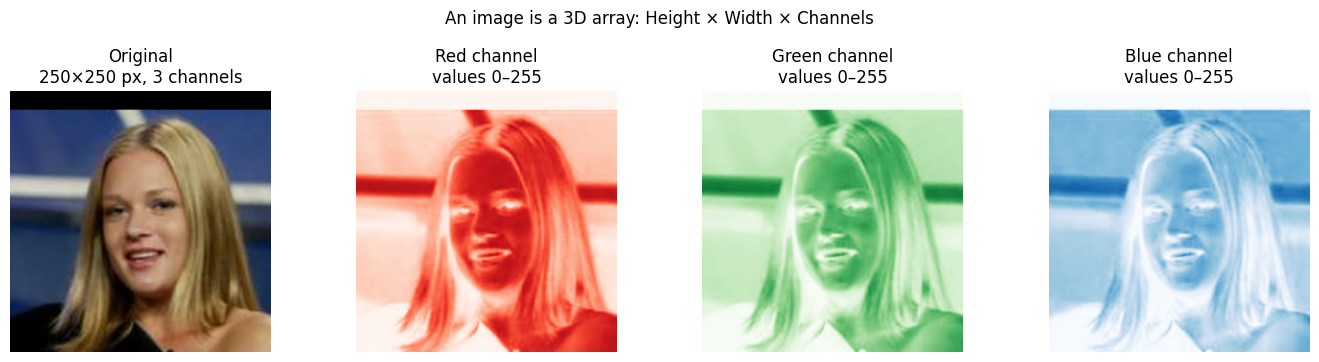

Array shape: (250, 250, 3)  |  dtype: uint8  |  value range: [0, 216]


In [6]:
def show_image_channels(image_path):
    img = np.array(Image.open(image_path).convert("RGB"))
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

    axes[0].imshow(img)
    axes[0].set_title(f"Original\n{img.shape[1]}×{img.shape[0]} px, 3 channels")

    channel_names = ["Red channel", "Green channel", "Blue channel"]
    cmaps         = ["Reds",        "Greens",         "Blues"]
    for i, (name, cmap) in enumerate(zip(channel_names, cmaps)):
        axes[i+1].imshow(img[:, :, i], cmap=cmap, vmin=0, vmax=255)
        axes[i+1].set_title(f"{name}\nvalues 0–255")

    for ax in axes:
        ax.axis("off")
    plt.suptitle("An image is a 3D array: Height × Width × Channels", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"Array shape: {img.shape}  |  dtype: {img.dtype}  |  "
          f"value range: [{img.min()}, {img.max()}]")

sample_path = next(FEMALE_PATH.glob('*.jpg'))
show_image_channels(sample_path)


### 🟢 Train / Validation / Benchmark — why three splits?

<div style="padding:14px 18px;border-radius:6px;margin:10px 0;background:rgba(33,150,243,0.08);border-left:5px solid #1976d2">

The dataset is divided into three non-overlapping groups, each serving a different purpose:

- **Train** — the model sees these images and updates its weights. This is where learning happens.
- **Validation** — used to monitor progress during training. Weights are **never** updated based on validation data.
- **Benchmark** — opened only once, at the very end. Never touched during development. Think of it as the exam.

</div>

<img src="https://raw.githubusercontent.com/FHNW-VISED/cvlab_notebooks/main/images/training_splits.jpeg" width="700"/>

---

**Q7.** How many images end up in train vs. validation?  
🔍 *Run after the person-aware split code runs:*
```python
print("Train:", len(train_idx), " Val:", len(val_idx))
```

**Q8.** Why can't we use the benchmark set to decide when to stop training?  
🔍 *Re-read the colored box above. The answer is in the definition of "Benchmark".*

---
# Part 2 · Transfer Learning — Quick Win 🚀

Pretrained models have already learned to recognise edges, textures, and shapes from millions of images.
We *borrow* that knowledge and add a small trainable layer on top for our specific task.

This is called **transfer learning** — and it's why we can get strong results in just a few minutes.


### 🟢 Backbone vs. classifier head

<div style="padding:14px 18px;border-radius:6px;margin:10px 0;background:rgba(33,150,243,0.08);border-left:5px solid #1976d2">

A pretrained CNN has two parts:

- **Backbone** (frozen 🧊) — the deep feature extractor, trained on 1.2 M ImageNet images. We don't change it.
- **Head** (trainable 🔥) — a tiny layer we attach on top. This is the only part we train.

We borrow the knowledge, add a small learnable layer on top for our specific task.

</div>


<img src="https://raw.githubusercontent.com/FHNW-VISED/cvlab_notebooks/main/images/transfer_learning.png" width="600"/>


### Data loading for transfer learning

The pretrained models expect images normalised with ImageNet statistics.
We use two separate transform pipelines: one for display, one for the model.


In [7]:
# @title Data transforms and ImageFolder datasets
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

display_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_PRETRAINED, IMG_SIZE_PRETRAINED)),
    transforms.ToTensor(),
])

if USE_DATA_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE_PRETRAINED, IMG_SIZE_PRETRAINED)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])
else:
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE_PRETRAINED, IMG_SIZE_PRETRAINED)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_PRETRAINED, IMG_SIZE_PRETRAINED)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# Build sample list directly — skip ImageFolder's generic tree walk entirely
# Scan female/ and male/ in parallel for maximum speed
from concurrent.futures import ThreadPoolExecutor

_classes     = ["female", "male"]
_class_to_idx = {c: i for i, c in enumerate(_classes)}

def _scan_class(args):
    cls, idx = args
    return sorted((str(f), idx) for f in (TRAIN_PATH / cls).glob("*.jpg"))

with ThreadPoolExecutor(max_workers=NUM_WORKERS if NUM_WORKERS > 0 else 1) as ex:
    _samples = [s for chunk in ex.map(_scan_class, _class_to_idx.items()) for s in chunk]

# Lightweight dataset: shares _samples, only swaps transform
class _FacesDataset(datasets.ImageFolder):
    def __init__(self, transform):
        self.root        = str(TRAIN_PATH)
        self.transform   = transform
        self.target_transform = None
        self.loader      = datasets.folder.default_loader
        self.extensions  = (".jpg",)
        self.classes     = _classes
        self.class_to_idx = _class_to_idx
        self.samples     = self.imgs = _samples

full_train_display = _FacesDataset(display_transform)
full_train_model   = _FacesDataset(train_transform)
full_train_eval    = _FacesDataset(eval_transform)
benchmark_display  = datasets.ImageFolder(BENCHMARK_PATH, transform=display_transform)
benchmark_model    = datasets.ImageFolder(BENCHMARK_PATH, transform=eval_transform)

pretrained_class_names = full_train_model.classes
num_classes = len(pretrained_class_names)
print("Classes:", pretrained_class_names)
print("Train images:", len(full_train_model))
print("Benchmark images:", len(benchmark_model))

Classes: ['female', 'male']
Train images: 4728
Benchmark images: 200


In [8]:
# Person-aware split — same person cannot appear in both train and validation
samples    = full_train_model.samples
persons    = np.array(['_'.join(Path(p).stem.split('_')[:-1]) for p, _ in samples])
labels_arr = np.array([lbl for _, lbl in samples])

rng = np.random.default_rng(SEED)
train_idx, val_idx = [], []

for label in np.unique(labels_arr):
    indices        = np.where(labels_arr == label)[0]
    unique_persons = np.unique(persons[indices])
    rng.shuffle(unique_persons)
    n_val = max(1, round(len(unique_persons) * VALIDATION_SPLIT))
    val_persons = set(unique_persons[:n_val])
    for i in indices:
        (val_idx if persons[i] in val_persons else train_idx).append(i)

train_idx = np.array(train_idx)
val_idx   = np.array(val_idx)

# Optional: subsample to N_IMAGES_PER_CLASS
if N_IMAGES_PER_CLASS is not None:
    _sub = []
    for _lbl in np.unique(labels_arr[train_idx]):
        _cls_idx = train_idx[labels_arr[train_idx] == _lbl]
        _n = min(N_IMAGES_PER_CLASS, len(_cls_idx))
        _sub.append(rng.choice(_cls_idx, size=_n, replace=False))
    train_idx = np.concatenate(_sub)
    rng.shuffle(train_idx)

pretrained_train_ds = Subset(full_train_model, train_idx)
pretrained_val_ds   = Subset(full_train_eval,  val_idx)
pretrained_train_disp = Subset(full_train_display, train_idx)

pretrained_train_loader = DataLoader(pretrained_train_ds, batch_size=BATCH_SIZE,
                                      shuffle=True, num_workers=0)
pretrained_val_loader   = DataLoader(pretrained_val_ds,   batch_size=BATCH_SIZE,
                                      shuffle=False, num_workers=0)
pretrained_bench_loader = DataLoader(benchmark_model, batch_size=BATCH_SIZE,
                                      shuffle=False, num_workers=0)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Benchmark: {len(benchmark_model)}")


Train: 500 | Val: 964 | Benchmark: 200


### 🟢 What does a batch look like?

Each training step processes `BATCH_SIZE` images at once. The grid below shows exactly one batch — this is what the model sees in a single forward pass.

<img src="https://raw.githubusercontent.com/FHNW-VISED/cvlab_notebooks/main/images/batch.png" width="700"/>

---

**Q9.** How many images does the model process in one training step?  
🔍 *Count the grid, or run: `print(BATCH_SIZE)`*

**Q10.** All images in the grid have the same size. Why does a neural network require fixed-size inputs?  
🔍 *Look at `build_pretrained_model` in the next section — find the `Linear` layer. Its input dimension is hard-coded. What happens if image sizes vary?*

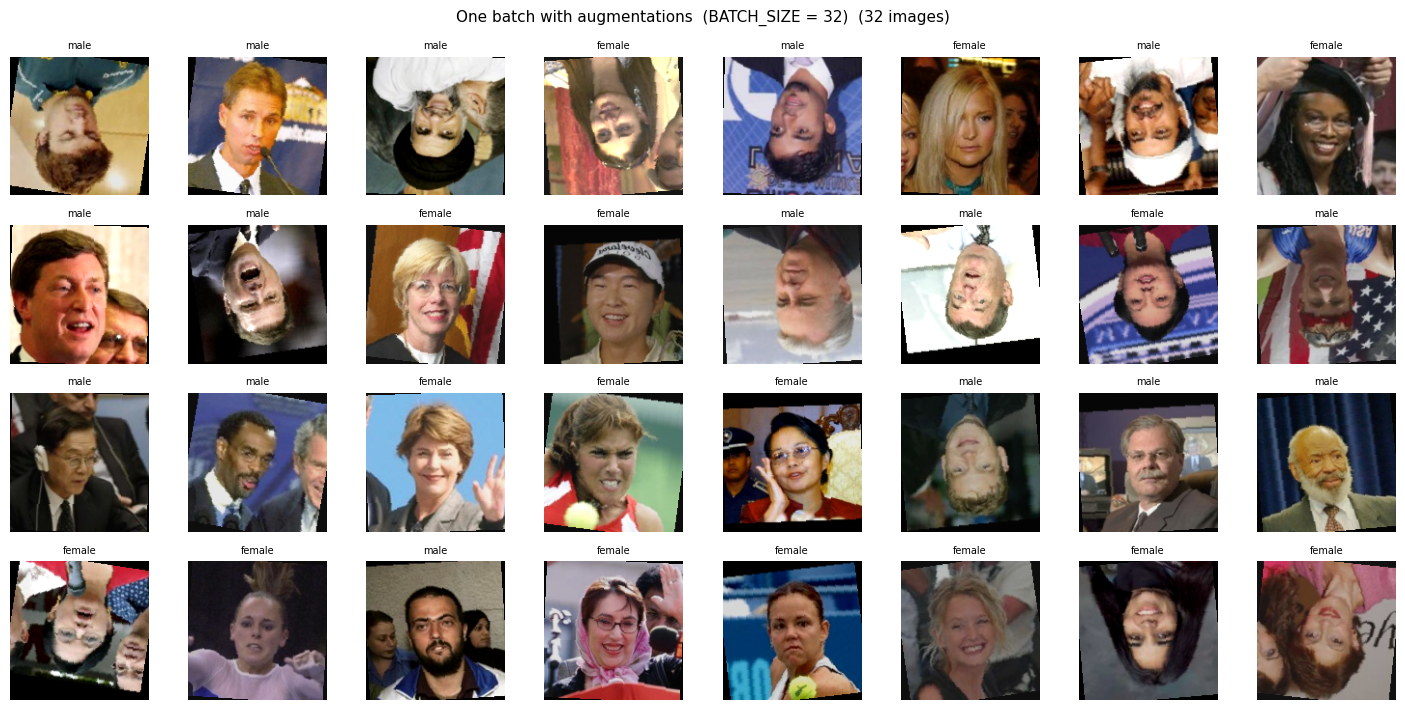

In [9]:
def show_batch(dataset, batch_size, class_names, title="One training batch"):
    n   = min(batch_size, len(dataset), 32)
    cols = min(n, 8)
    rows = int(np.ceil(n / cols))
    rng_ = np.random.default_rng(SEED)
    idxs = rng_.choice(len(dataset), size=n, replace=False)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 1.8))
    axes = np.array(axes).flatten()
    for i, ax in enumerate(axes):
        if i < n:
            img, label = dataset[int(idxs[i])]
            if isinstance(img, torch.Tensor):
                img = img.permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)
            ax.imshow(img)
            ax.set_title(class_names[label], fontsize=7)
        ax.axis("off")
    plt.suptitle(f"{title}  ({n} images)", fontsize=11)
    plt.tight_layout()
    plt.show()

aug_display_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_PRETRAINED, IMG_SIZE_PRETRAINED)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),  # no Normalize — keeps natural colours
])
aug_display_ds = Subset(_FacesDataset(aug_display_transform), train_idx)

show_batch(aug_display_ds, BATCH_SIZE, pretrained_class_names,
           title=f"One batch with augmentations  (BATCH_SIZE = {BATCH_SIZE})")


### 🟢 Try it yourself — how much data do you need?

**Change the single number below, then re-run from the "1. Workshop control panel" cell.**

| Value | Effect |
|-------|--------|
| `50`  | Very few images — model will likely underfit |
| `200` | Moderate dataset |
| `500` | Default — good balance of speed and accuracy |
| `None` | Use all available images |

```python
N_IMAGES_PER_CLASS = 50  # ← change this one number
```

Re-run training and see how accuracy changes. This is the fastest way to observe **how data quantity drives learning**.

---

**Q15.** Set `N_IMAGES_PER_CLASS = 50`, train, note the benchmark accuracy. Then try `500`. How much does accuracy change?  
🔍 *After each run, read the benchmark accuracy printed after training completes. Record both numbers.*

### Build the pretrained model


In [10]:
def build_pretrained_model(model_name=MODEL_NAME, num_classes=2, dropout=0.0,
                            freeze_backbone=True, unfreeze_last_block=False,
                            img_size=IMG_SIZE_PRETRAINED):
    if model_name == "mobilenet_v2":
        base = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V2)
        if freeze_backbone:
            for p in base.features.parameters(): p.requires_grad = False
        if unfreeze_last_block:
            for p in base.features[-1].parameters(): p.requires_grad = True
        in_f = base.classifier[1].in_features
        base.classifier = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_f, num_classes))

    elif model_name == "resnet50":
        base = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        if freeze_backbone:
            for name, p in base.named_parameters():
                if not name.startswith("fc"): p.requires_grad = False
        if unfreeze_last_block:
            for p in base.layer4.parameters(): p.requires_grad = True
        in_f = base.fc.in_features
        base.fc = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_f, num_classes))

    elif model_name == "vit_b_16":
        base = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for name, p in base.named_parameters():
                if not name.startswith("heads"): p.requires_grad = False
        if unfreeze_last_block:
            for p in base.encoder.layers[-1].parameters(): p.requires_grad = True
        in_f = base.heads.head.in_features
        base.heads.head = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_f, num_classes))
    else:
        raise ValueError(f"Unknown MODEL_NAME {model_name!r}")
    return base

pretrained_model = build_pretrained_model(
    model_name=MODEL_NAME, num_classes=num_classes,
    dropout=DROPOUT_PRETRAINED, freeze_backbone=FREEZE_BACKBONE,
    unfreeze_last_block=UNFREEZE_LAST_BLOCK,
).to(device)

total_p     = sum(p.numel() for p in pretrained_model.parameters())
trainable_p = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
print(f"Backbone:         {MODEL_NAME}  (frozen={FREEZE_BACKBONE})")
print(f"Total params:     {total_p:,}")
print(f"Trainable params: {trainable_p:,}  ({100*trainable_p/total_p:.1f}%)")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 132MB/s]


Backbone:         mobilenet_v2  (frozen=True)
Total params:     2,226,434
Trainable params: 2,562  (0.1%)


### 🟢 Checkpoint

**Q11.** How many parameters are we actually training vs. how many are frozen?  
🔍 *Run in a new cell:*
```python
total     = sum(p.numel() for p in pretrained_model.parameters())
trainable = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
print(f"Total: {total:,}   Trainable: {trainable:,}   Frozen: {total-trainable:,}")
```

**Q12.** Why is training so fast if the model has millions of parameters?  
🔍 *Compare `trainable` vs `total` from Q11. Backprop only runs through layers where `requires_grad=True`.*

---

🟡 **Q24.** Predict: if you set `UNFREEZE_LAST_BLOCK = True`, how will the trainable count change?  
Write your prediction, then do it: set `UNFREEZE_LAST_BLOCK = True` in the control panel, re-run the model build code, then run Q11's snippet again.

🟡 **Q25.** After re-training with `UNFREEZE_LAST_BLOCK = True`, does benchmark accuracy improve?  
🔍 *Re-run training and evaluation, then compare `pretrained_bench_metrics['accuracy']` to your earlier frozen-backbone result.*

In [11]:
# @title Training utilities (transfer learning)
# Training utilities
_scaler = torch.cuda.amp.GradScaler() if device == "cuda" else None

def train_one_epoch_pretrained(model, dataloader, criterion, optimizer):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    use_amp = device == "cuda"
    for images, labels in tqdm(dataloader, leave=False, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.autocast(device_type=device, enabled=use_amp):
            logits = model(images)
            loss   = criterion(logits, labels)
        if use_amp:
            _scaler.scale(loss).backward(); _scaler.step(optimizer); _scaler.update()
        else:
            loss.backward(); optimizer.step()
        running_loss    += loss.item() * images.size(0)
        running_correct += (logits.argmax(1) == labels).sum().item()
        running_total   += labels.size(0)
    return {"loss": running_loss / running_total, "accuracy": running_correct / running_total}


@torch.no_grad()
def evaluate_pretrained(model, dataloader, criterion):
    from sklearn.metrics import accuracy_score, f1_score
    model.eval()
    running_loss, running_total = 0.0, 0
    all_labels, all_preds = [], []
    use_amp = device == "cuda"
    for images, labels in tqdm(dataloader, leave=False, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)
        with torch.autocast(device_type=device, enabled=use_amp):
            logits = model(images); loss = criterion(logits, labels)
        preds = logits.argmax(1)
        running_loss  += loss.item() * images.size(0)
        running_total += labels.size(0)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
    ln, pn = np.array(all_labels), np.array(all_preds)
    return {"loss": running_loss / running_total,
            "accuracy": accuracy_score(ln, pn),
            "f1": f1_score(ln, pn, average="weighted", zero_division=0),
            "labels": ln, "preds": pn}


def fit_pretrained(model, train_loader, val_loader, criterion, optimizer, epochs):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
    model.eval()
    with torch.no_grad():
        imgs, _ = next(iter(train_loader))
        model(imgs[:1].to(device))  # warmup

    for epoch in tqdm(range(1, epochs + 1), desc="Training", unit="epoch"):
        tm = train_one_epoch_pretrained(model, train_loader, criterion, optimizer)
        vm = evaluate_pretrained(model, val_loader, criterion)
        history["train_loss"].append(tm["loss"]); history["train_acc"].append(tm["accuracy"])
        history["val_loss"].append(vm["loss"]);   history["val_acc"].append(vm["accuracy"])
        history["val_f1"].append(vm["f1"])
        print(f"Epoch {epoch:02d}/{epochs} | train_loss={tm['loss']:.4f} "
              f"val_loss={vm['loss']:.4f} val_acc={vm['accuracy']:.4f} val_f1={vm['f1']:.4f}")
    return history


def plot_history(history, title="Learning curves"):
    if len(history.get("train_loss", [])) < 2:
        print("Need at least 2 epochs to plot curves. Increase EPOCHS and re-run.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"],   label="validation")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[1].plot(epochs, history["train_acc"], label="train")
    axes[1].plot(epochs, history["val_acc"],   label="validation")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.suptitle(title); plt.tight_layout(); plt.show()


In [12]:
# Results are persisted to a JSON file so they survive kernel restarts
# and are never wiped by accidentally re-running this cell.
import json as _json
from datetime import datetime as _dt

RESULTS_PATH = DATA_PATH / "results"
RESULTS_PATH.mkdir(parents=True, exist_ok=True)
RESULTS_FILE = RESULTS_PATH / "runs.json"

def _load_results():
    if RESULTS_FILE.exists():
        with open(RESULTS_FILE) as _f:
            return _json.load(_f)
    return {}

def _save_result(key, metrics):
    runs = _load_results()
    if key in runs:
        print(f"[results] Updating existing entry: {key}")
    else:
        print(f"[results] Saving new entry: {key}")
    runs[key] = {**metrics, "saved_at": _dt.now().isoformat(timespec="seconds")}
    with open(RESULTS_FILE, "w") as _f:
        _json.dump(runs, _f, indent=2)

print(f"Results file: {RESULTS_FILE}")


Results file: /content/drive/MyDrive/cvlab_workshop/results/runs.json


In [13]:
# Train the pretrained model
pretrained_loss_fn  = nn.CrossEntropyLoss()
pretrained_optimizer = Adam(
    [p for p in pretrained_model.parameters() if p.requires_grad],
    lr=LR_PRETRAINED
)

pretrained_history = fit_pretrained(
    pretrained_model, pretrained_train_loader, pretrained_val_loader,
    pretrained_loss_fn, pretrained_optimizer, EPOCHS_PRETRAINED
)


Training:   0%|          | 0/4 [00:00<?, ?epoch/s]

Training:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 01/4 | train_loss=0.6695 val_loss=0.6494 val_acc=0.6587 val_f1=0.6522


Training:   0%|          | 0/16 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 03/4 | train_loss=0.6170 val_loss=0.6202 val_acc=0.7095 val_f1=0.7110


Training:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 04/4 | train_loss=0.5935 val_loss=0.6009 val_acc=0.7334 val_f1=0.7326


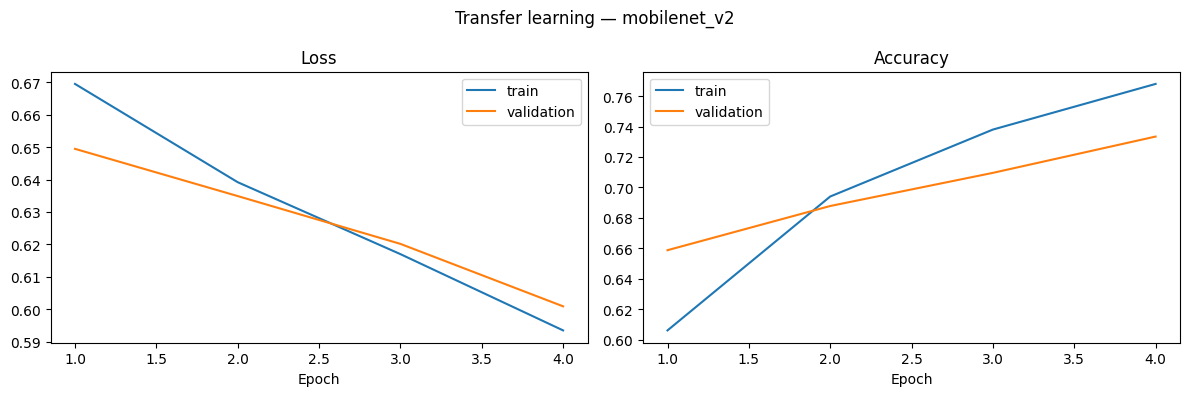

In [14]:
plot_history(pretrained_history, title=f"Transfer learning — {MODEL_NAME}")


### 🟢 Evaluate on benchmark

The benchmark set was never touched during training. Let's see how the model actually performs.

**Q13.** Write your prediction first: will benchmark accuracy be **higher**, **lower**, or the **same** as validation?  
*(Write it down before running the cell below.)*

🔍 *After running, check the gap:*
```python
gap = pretrained_bench_metrics['accuracy'] - pretrained_val_metrics['accuracy']
print(f"Validation: {pretrained_val_metrics['accuracy']:.4f}")
print(f"Benchmark:  {pretrained_bench_metrics['accuracy']:.4f}")
print(f"Gap:        {gap:+.4f}")
```

**Q14.** What does a large negative gap (val >> benchmark) tell you about the training data?  
🔍 *No code — think about where each set comes from and what a big gap implies.*

Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Validation  — accuracy: 0.7334  F1: 0.7326
Benchmark   — accuracy: 0.7700  F1: 0.7700


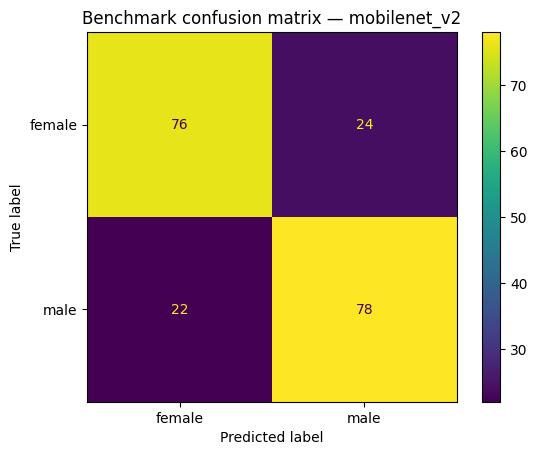

In [15]:
pretrained_val_metrics   = evaluate_pretrained(pretrained_model, pretrained_val_loader, pretrained_loss_fn)
pretrained_bench_metrics = evaluate_pretrained(pretrained_model, pretrained_bench_loader, pretrained_loss_fn)

print(f"Validation  — accuracy: {pretrained_val_metrics['accuracy']:.4f}  F1: {pretrained_val_metrics['f1']:.4f}")
print(f"Benchmark   — accuracy: {pretrained_bench_metrics['accuracy']:.4f}  F1: {pretrained_bench_metrics['f1']:.4f}")

ConfusionMatrixDisplay.from_predictions(
    pretrained_bench_metrics["labels"], pretrained_bench_metrics["preds"],
    display_labels=pretrained_class_names
)
plt.title(f"Benchmark confusion matrix — {MODEL_NAME}")
plt.show()


### 🟡 Quick experiments — try one change

**Rule: write your prediction before you run each experiment.**

Change a value in the control panel, then re-run from the experiment config cell.

| # | Change | Predict first | What to check |
|---|--------|---------------|---------------|
| 1 | `EPOCHS_PRETRAINED = 8` | Will val accuracy keep rising after epoch 4? | Val accuracy curve |
| 2 | `USE_DATA_AUGMENTATION = True` | Will train-val gap shrink? | `pretrained_history['train_acc'][-1] - pretrained_history['val_acc'][-1]` |
| 3 | `FREEZE_BACKBONE = False` | How many more params get trained? | Run Q11 snippet again |
| 4 | `MODEL_NAME = "resnet50"` | Faster or slower than MobileNetV2? Better accuracy? | tqdm time + benchmark accuracy |

🔴 **Expert track:** `FREEZE_BACKBONE = False` + `LR_PRETRAINED = 1e-5` — this is full fine-tuning.  
Why use `1e-5` and not the default `1e-4`? What breaks if you use a high learning rate on a pretrained backbone?

---
# Part 3 · Build a CNN from Scratch 🔧

Now we build the neural network ourselves — every layer, by hand.

This takes longer to train and usually performs worse than transfer learning.
But understanding how it works helps you understand *why* pretrained models are so powerful.


### 🟢 How does a convolution work?

A convolution slides a small **kernel** (filter) across the image. At each position it multiplies the kernel values by the image values underneath and sums them. This detects local patterns like edges or corners.

The cell below shows this for a tiny example.


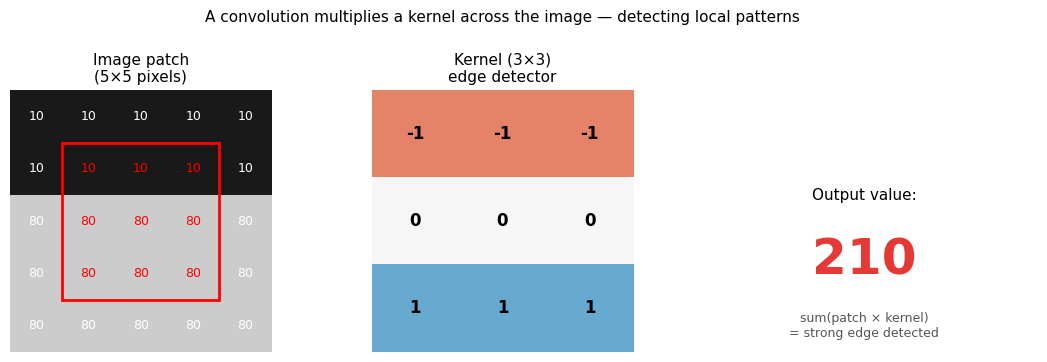

In [16]:
def plot_convolution_intuition():
    np.random.seed(0)
    img_patch = np.array([
        [10, 10, 10, 10, 10],
        [10, 10, 10, 10, 10],
        [80, 80, 80, 80, 80],
        [80, 80, 80, 80, 80],
        [80, 80, 80, 80, 80],
    ], dtype=float)

    kernel = np.array([
        [-1, -1, -1],
        [ 0,  0,  0],
        [ 1,  1,  1],
    ], dtype=float)

    # Apply convolution (manual, center position only for demo)
    r, c = 1, 1   # top-left of kernel placement
    patch_under = img_patch[r:r+3, c:c+3]
    result_val  = float(np.sum(patch_under * kernel))

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))

    # Image patch
    im0 = axes[0].imshow(img_patch, cmap="gray", vmin=0, vmax=100)
    axes[0].set_title("Image patch\n(5×5 pixels)", fontsize=11)
    for i in range(5):
        for j in range(5):
            axes[0].text(j, i, int(img_patch[i, j]), ha="center", va="center",
                         fontsize=9, color="red" if (r<=i<=r+2 and c<=j<=c+2) else "white")
    rect = plt.Rectangle((c-0.5, r-0.5), 3, 3, edgecolor="red", facecolor="none", lw=2)
    axes[0].add_patch(rect)
    axes[0].axis("off")

    # Kernel
    im1 = axes[1].imshow(kernel, cmap="RdBu", vmin=-2, vmax=2)
    axes[1].set_title("Kernel (3×3)\nedge detector", fontsize=11)
    for i in range(3):
        for j in range(3):
            axes[1].text(j, i, int(kernel[i, j]), ha="center", va="center",
                         fontsize=12, fontweight="bold")
    axes[1].axis("off")

    # Output value
    axes[2].axis("off")
    axes[2].text(0.5, 0.6, "Output value:", ha="center", va="center",
                 fontsize=11, transform=axes[2].transAxes)
    axes[2].text(0.5, 0.35, f"{result_val:.0f}", ha="center", va="center",
                 fontsize=36, fontweight="bold", color="#e53935",
                 transform=axes[2].transAxes)
    axes[2].text(0.5, 0.1, "sum(patch × kernel)\n= strong edge detected",
                 ha="center", va="center", fontsize=9, color="#555",
                 transform=axes[2].transAxes)

    plt.suptitle("A convolution multiplies a kernel across the image — detecting local patterns",
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

plot_convolution_intuition()


### 🔗 Interactive CNN visualisers

Before writing code, explore how convolutions and networks actually work — visually:

| Tool | What it shows |
|------|---------------|
| [CNN Playground](https://cnn-playground.live/imagenet) | Feature visualisation on ImageNet — what each filter responds to |
| [CNN Explainer](https://poloclub.github.io/cnn-explainer/) | Step-by-step interactive view of every operation in a small CNN |
| [3D Neural Network Vis](https://adamharley.com/nn_vis/cnn/3d.html) | 3-D interactive view of activations flowing through the network |

Open one, draw a digit or upload a photo, and watch the activations change. Then come back and write your own layers below.


### Preprocess images for the handcrafted CNN

The handcrafted model uses OpenCV for image loading and a simpler normalisation (values in [0, 1]).


In [17]:
# Class names alias (same as pretrained section — CNN trains on same data)
cnn_class_names = pretrained_class_names


### Define the CNN architecture


In [18]:
class ConvModule(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1,
                 dropout_ratio=0.0, use_batchnorm=False):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, kernel_size, padding=padding)]
        if use_batchnorm: layers.append(nn.BatchNorm2d(out_ch))
        layers += [nn.ReLU(), nn.Dropout2d(dropout_ratio), nn.MaxPool2d(2)]
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class HandcraftedCNN(nn.Module):
    def __init__(self, num_classes=2, num_channels=32,
                 dropout_ratio=0.0, use_batchnorm=True, img_size=IMG_SIZE_CNN):
        super().__init__()
        self.model_parameters = dict(num_classes=num_classes,
                                     num_channels=num_channels,
                                     dropout_ratio=dropout_ratio,
                                     use_batchnorm=use_batchnorm)
        self.features = nn.Sequential(
            ConvModule(3,             num_channels,     dropout_ratio=dropout_ratio, use_batchnorm=use_batchnorm),
            ConvModule(num_channels,  num_channels * 2, dropout_ratio=dropout_ratio, use_batchnorm=use_batchnorm),
            ConvModule(num_channels*2, num_channels * 4, dropout_ratio=dropout_ratio, use_batchnorm=use_batchnorm),
        )
        with torch.no_grad():
            n_feat = self.features(torch.zeros(1, 3, img_size, img_size)).flatten(1).shape[1]
        self.classifier = nn.Sequential(
            nn.Linear(n_feat, 128), nn.ReLU(),
            nn.Dropout(dropout_ratio), nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))
    def save_weights(self, path): torch.save(self.state_dict(), path)


### 🟢 Architecture diagram — what happens to the spatial size?

Each `ConvModule` applies a MaxPool that halves the spatial dimensions. The number of channels grows.

---

**Q.** Starting from an image of size `144×144`, what is the spatial size after each of the 3 ConvModules?  
🔍 *Trace it manually: 144 → ? → ? → ? (divide by 2 each step). Then verify:*
```python
import torch
dummy = torch.zeros(1, 3, 144, 144).to(device)
cnn_model.eval()
with torch.no_grad():
    x = dummy
    for i, block in enumerate(cnn_model.features):
        x = block(x)
        print(f"After block {i+1}: {x.shape}")
```
*(Run after the experiment zone code where `cnn_model` is defined.)*

### 🟢 Sanity check: can the model overfit 10 images?

Before full training, we check that the model *can* learn at all. We train on just 10 images — the model should reach 100% training accuracy quickly. If it can't fit 10 images, something is wrong.

---

**Q16.** What training accuracy does the tiny model reach after 20 epochs on 10 images?  
🔍 *After the sanity-check training loop runs, check the last value:*
```python
print(f"Final train acc: {tiny_history['train_acc'][-1]:.3f}")
```

**Q17.** If the model *couldn't* reach 100% on 10 images, what would that tell you?  
🔍 *Look at `HandcraftedCNN` defined in the architecture section. A model that can't overfit 10 samples either has wrong input dimensions, a bug in forward(), or is too shallow. Which do you think it would be?*

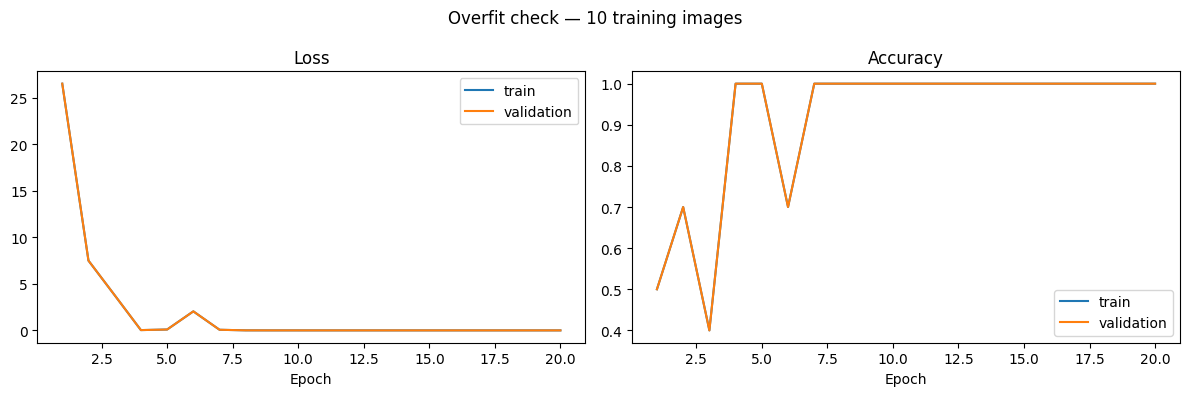

Final train accuracy on 10 samples: 100.0%


In [19]:
tiny_model   = HandcraftedCNN(num_channels=32, dropout_ratio=0.0, use_batchnorm=True, img_size=IMG_SIZE_PRETRAINED).to(device)
tiny_loss_fn = nn.CrossEntropyLoss()
tiny_optim   = Adam(tiny_model.parameters(), lr=1e-3)

# 10-image subset reused from the same training split (comparable with pretrained)
overfit_ds     = Subset(full_train_model, train_idx[:10])
overfit_loader = DataLoader(overfit_ds, batch_size=5, shuffle=True)

tiny_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(20):
    tiny_model.train()
    ep_loss, correct, total = 0.0, 0, 0
    for xb, yb in overfit_loader:
        xb, yb = xb.to(device), yb.to(device)
        tiny_optim.zero_grad()
        logits = tiny_model(xb); loss = tiny_loss_fn(logits, yb)
        loss.backward(); tiny_optim.step()
        ep_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item(); total += xb.size(0)
    tiny_history["train_loss"].append(ep_loss / total)
    tiny_history["train_acc"].append(correct / total)
    tiny_history["val_loss"].append(ep_loss / total)
    tiny_history["val_acc"].append(correct / total)

plot_history(tiny_history, title="Overfit check — 10 training images")
print(f"Final train accuracy on 10 samples: {tiny_history['train_acc'][-1]:.1%}")


### 🟡 Train the full handcrafted CNN

Now train on the full dataset. This will take longer than the pretrained model.

**Before running: write down your predictions.**

**Q29.** Will the CNN overfit? (train accuracy >> val accuracy)  
🔍 *After training, check:*
```python
print(f"Train: {cnn_history['train_acc'][-1]:.3f}  Val: {cnn_history['val_acc'][-1]:.3f}")
print(f"Gap:   {cnn_history['train_acc'][-1] - cnn_history['val_acc'][-1]:+.3f}")
```

**Q30.** Will it beat the pretrained model on benchmark accuracy?  
🔍 *After running the experiment zone and the benchmark evaluation, compare:*
```python
print(f"CNN benchmark:        {cnn_bench_m['accuracy']:.4f}")
print(f"Pretrained benchmark: {pretrained_bench_metrics['accuracy']:.4f}")
```

In [20]:
# ╔══════════════════════════════════════════════════╗
# ║  ✏️  Experiment zone — change and re-run         ║
# ╚══════════════════════════════════════════════════╝
EXP_CNN_EPOCHS    = EPOCHS_CNN
EXP_CNN_LR        = LR_CNN
EXP_NUM_CHANNELS  = NUM_CHANNELS
EXP_DROPOUT_CNN   = DROPOUT_CNN
EXP_USE_BATCHNORM = USE_BATCHNORM

# Rebuild model (ensures a fresh start every run)
cnn_model = HandcraftedCNN(
    num_channels=EXP_NUM_CHANNELS, dropout_ratio=EXP_DROPOUT_CNN,
    use_batchnorm=EXP_USE_BATCHNORM, img_size=IMG_SIZE_PRETRAINED
).to(device)
cnn_loss_fn  = nn.CrossEntropyLoss()
cnn_optim    = Adam(cnn_model.parameters(), lr=EXP_CNN_LR)

total_cnn, trainable_cnn = (sum(p.numel() for p in cnn_model.parameters()),
                             sum(p.numel() for p in cnn_model.parameters() if p.requires_grad))
print(f"Model ready | params: {total_cnn:,} | LR: {EXP_CNN_LR} | epochs: {EXP_CNN_EPOCHS}")


Model ready | params: 5,402,050 | LR: 0.001 | epochs: 20


In [ ]:
# Training loop — reuses pretrained_train_loader and pretrained_val_loader
# (same images, same split → directly comparable results)
cnn_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in tqdm(range(1, EXP_CNN_EPOCHS + 1), desc="Training CNN", unit="epoch"):
    cnn_model.train()
    ep_loss, correct, total = 0.0, 0, 0
    for xb, yb in pretrained_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        cnn_optim.zero_grad()
        logits = cnn_model(xb); loss = cnn_loss_fn(logits, yb)
        loss.backward(); cnn_optim.step()
        ep_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item(); total += xb.size(0)
    tm_loss = ep_loss / total; tm_acc = correct / total
    vm = evaluate_pretrained(cnn_model, pretrained_val_loader, cnn_loss_fn)
    cnn_history["train_loss"].append(tm_loss); cnn_history["train_acc"].append(tm_acc)
    cnn_history["val_loss"].append(vm["loss"]); cnn_history["val_acc"].append(vm["accuracy"])
    print(f"Epoch {epoch:02d}/{EXP_CNN_EPOCHS} | train_loss={tm_loss:.4f} "
          f"val_loss={vm['loss']:.4f} val_acc={vm['accuracy']:.4f} val_f1={vm['f1']:.4f}")


Training CNN:   0%|          | 0/20 [00:00<?, ?epoch/s]

Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 01/20 | train_loss=0.7454 val_loss=0.6845 val_acc=0.5768 val_f1=0.4219


Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 02/20 | train_loss=0.6773 val_loss=0.7470 val_acc=0.4585 val_f1=0.3506


...

Epoch 16/20 | train_loss=0.0018 val_loss=1.3028 val_acc=0.7490 val_f1=0.7498


Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 17/20 | train_loss=0.0046 val_loss=1.3411 val_acc=0.7780 val_f1=0.7758


Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 18/20 | train_loss=0.0018 val_loss=1.3307 val_acc=0.7604 val_f1=0.7597


In [ ]:
plot_history(cnn_history, title="Handcrafted CNN learning curves")


#### 🟢 Reflection

**Q18.** Is the model still improving at the last epoch, or has it plateaued?  
🔍 *Check the last 3 values:*
```python
print("Last 3 train acc:", cnn_history['train_acc'][-3:])
print("Last 3 val acc:  ", cnn_history['val_acc'][-3:])
```

**Q19.** How large is the train-val gap? What does a large gap mean?  
🔍 *Run:* `print(f"Gap: {cnn_history['train_acc'][-1] - cnn_history['val_acc'][-1]:+.3f}")`

**Q20** *(after the Part 4 comparison table runs)*. Which model has higher benchmark accuracy, and by how much?  
🔍 *Run after the side-by-side comparison:* `print(comparison_df.to_string())`

---

🟡 **Experiments — change one value in the experiment zone and re-run training:**

| Change (in the experiment zone) | Predict first | What to check |
|--------|---------------|---------------|
| `EXP_DROPOUT_CNN = 0.3` | Will val curve become smoother? | Train-val gap |
| `EXP_NUM_CHANNELS = 64` | Better accuracy? Worth the time? | Benchmark acc + tqdm time |
| `EXP_USE_BATCHNORM = True` | More stable training? | `np.std(cnn_history['val_loss'])` |

🔴 **Advanced — architecture search:** try all three combinations and record benchmark accuracy:

| NUM_CHANNELS | DROPOUT_CNN | USE_BATCHNORM | benchmark_acc |
|---|---|---|---|
| 32 | 0.0 | False | *(default)* |
| 32 | 0.3 | True | ? |
| 64 | 0.3 | True | ? |

Can you beat the pretrained model's benchmark accuracy with the handcrafted CNN?

---
# Part 4 · Compare & Interpret

Let's load the benchmark set for the handcrafted model and do a side-by-side comparison.


In [ ]:
# Build display arrays directly from benchmark_display
# (same dataset/transform used by the pretrained side — no separate loading needed)
X_bench = np.stack([img.permute(1, 2, 0).numpy() for img, _ in benchmark_display])
y_bench = np.array([lbl for _, lbl in benchmark_display], dtype=np.int64)
print(f"Benchmark display array: {X_bench.shape}")


In [ ]:
# Side-by-side comparison (both models evaluated on the same benchmark loader)
cnn_bench_m = evaluate_pretrained(cnn_model, pretrained_bench_loader, cnn_loss_fn)
cnn_val_m   = evaluate_pretrained(cnn_model, pretrained_val_loader,   cnn_loss_fn)

comparison_df = pd.DataFrame([
    {"model": f"Transfer ({MODEL_NAME})", "split": "validation",
     "accuracy": pretrained_val_metrics["accuracy"], "F1": pretrained_val_metrics["f1"]},
    {"model": f"Transfer ({MODEL_NAME})", "split": "benchmark",
     "accuracy": pretrained_bench_metrics["accuracy"], "F1": pretrained_bench_metrics["f1"]},
    {"model": "Handcrafted CNN",          "split": "validation",
     "accuracy": cnn_val_m["accuracy"],   "F1": cnn_val_m["f1"]},
    {"model": "Handcrafted CNN",          "split": "benchmark",
     "accuracy": cnn_bench_m["accuracy"], "F1": cnn_bench_m["f1"]},
]).round(4)

print(comparison_df.to_string(index=False))

# Persist to JSON
_save_result(f"{MODEL_NAME}_ep{EPOCHS_PRETRAINED}_freeze{int(FREEZE_BACKBONE)}", {
    "model": f"Transfer ({MODEL_NAME})", "epochs": EPOCHS_PRETRAINED,
    "freeze_backbone": FREEZE_BACKBONE,
    "val_acc":   pretrained_val_metrics["accuracy"], "val_f1":   pretrained_val_metrics["f1"],
    "bench_acc": pretrained_bench_metrics["accuracy"], "bench_f1": pretrained_bench_metrics["f1"],
})
_save_result(f"CNN_ch{EXP_NUM_CHANNELS}_ep{EXP_CNN_EPOCHS}_do{EXP_DROPOUT_CNN}_bn{int(EXP_USE_BATCHNORM)}", {
    "model": "Handcrafted CNN", "epochs": EXP_CNN_EPOCHS,
    "num_channels": EXP_NUM_CHANNELS, "dropout": EXP_DROPOUT_CNN, "batchnorm": EXP_USE_BATCHNORM,
    "val_acc":   cnn_val_m["accuracy"],   "val_f1":   cnn_val_m["f1"],
    "bench_acc": cnn_bench_m["accuracy"], "bench_f1": cnn_bench_m["f1"],
})


In [ ]:
# ── Cross-run comparison ─────────────────────────────────────────────────────
# Loads every run ever saved to disk — survives kernel restarts.
_runs = _load_results()
if _runs:
    df = pd.DataFrame(_runs).T
    df = df[["model", "val_acc", "val_f1", "bench_acc", "bench_f1", "saved_at"]].rename(columns={
        "val_acc": "Val Acc", "val_f1": "Val F1",
        "bench_acc": "Bench Acc", "bench_f1": "Bench F1",
        "saved_at": "Saved at",
    })
    for col in ["Val Acc", "Val F1", "Bench Acc", "Bench F1"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").round(4)
    print(f"\n=== Results across all runs ({len(df)} total) ===\n")
    try:
        display(df.style.highlight_max(subset=["Val Acc","Val F1","Bench Acc","Bench F1"],
                                       color="#c8f7c5", axis=0).format(
            {c: "{:.4f}" for c in ["Val Acc","Val F1","Bench Acc","Bench F1"]}))
    except Exception:
        print(df.to_string())
else:
    print(f"No results yet — train at least one model first.\nExpected file: {RESULTS_FILE}")


### 🟢 Checkpoint — discuss with a neighbour

**Q20.** Which model performs better on the benchmark? By how much?  
🔍 *Run:* `print(comparison_df[['model','split','accuracy']].to_string())`

**Q21.** The pretrained model trained for only 4 epochs. The CNN trained for 20. Yet the pretrained model wins. Why?  
🔍 *Re-read the "Backbone vs. classifier head" section. What did ImageNet pre-training provide that the CNN has to learn from scratch?*

**Q.** Which model's confusion matrix shows a clearer pattern of errors?  
🔍 *Look at the confusion matrices in the section below — which has more off-diagonal mass, and in which direction?*

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(
    pretrained_bench_metrics["labels"], pretrained_bench_metrics["preds"],
    display_labels=pretrained_class_names, ax=axes[0]
)
axes[0].set_title(f"Transfer learning ({MODEL_NAME})")

ConfusionMatrixDisplay.from_predictions(
    cnn_bench_m["y_true"], cnn_bench_m["y_pred"],
    display_labels=cnn_class_names, ax=axes[1]
)
axes[1].set_title("Handcrafted CNN")
plt.tight_layout()
plt.show()


### 🟡 Browse predictions — find interesting cases

Use the browser below to find:
- A **highly confident correct** prediction
- A **highly confident mistake**
- An **uncertain** prediction (probability close to 0.5)

**Q34.** What index has the highest confidence prediction? Is it correct?  
🔍 *Run in a new cell:*
```python
max_i = int(np.argmax(cnn_probs.max(axis=1)))
print(f"Index {max_i}  conf={cnn_probs[max_i].max():.3f}  "
      f"pred={cnn_class_names[cnn_preds[max_i]]}  true={cnn_class_names[y_bench[max_i]]}")
```

**Q35.** The most confident *wrong* prediction is shown first in the error browser below (sorted by confidence). What confidence does it have?  
🔍 *The title of the first image in the error browser below shows the confidence.*

**Q36.** What is the index of the most uncertain prediction (closest to 0.5)?  
🔍 *Run in a new cell:*
```python
uncertain_i = int(np.argmin(np.abs(cnn_probs.max(axis=1) - 0.5)))
print(f"Index {uncertain_i}  conf={cnn_probs[uncertain_i].max():.3f}")
```
Navigate to that index in the browser above. Why is the model uncertain on this image?

In [ ]:
# CNN inference uses normalized benchmark_model tensors — same pipeline as training
cnn_model.eval()
with torch.no_grad():
    _logits = [cnn_model(xb.to(device)).cpu()
               for xb, _ in DataLoader(benchmark_model, batch_size=64, num_workers=0)]
    cnn_probs = torch.softmax(torch.cat(_logits), dim=1).numpy()
    cnn_preds = np.argmax(cnn_probs, axis=1)


def show_prediction(X_, y_true, probs_, class_names_, i, title=""):
    pred = int(np.argmax(probs_[i]))
    correct = pred == y_true[i]
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].imshow(X_[i])
    color = "green" if correct else "red"
    axes[0].set_title(f"True: {class_names_[y_true[i]]}\n"
                      f"Pred: {class_names_[pred]} {'✓' if correct else '✗'}",
                      color=color)
    axes[0].axis("off")
    bar_colors = [color if i == pred else "#90caf9" for i in range(len(class_names_))]
    axes[1].bar(class_names_, probs_[i], color=bar_colors)
    axes[1].set_ylim(0, 1); axes[1].set_title(f"Confidence  {title}")
    plt.tight_layout(); plt.show()


if USE_INTERACTIVE:
    max_idx  = len(X_bench) - 1
    slider   = widgets.IntSlider(value=0, min=0, max=max_idx, step=1,
                                 description="sample", continuous_update=False,
                                 layout=widgets.Layout(width="500px"))
    prev_btn = widgets.Button(description="◀ Previous")
    next_btn = widgets.Button(description="Next ▶")
    out      = widgets.Output()

    def render_pred(i):
        with out:
            out.clear_output(wait=True)
            show_prediction(X_bench, y_bench, cnn_probs, cnn_class_names, i,
                            title="(Handcrafted CNN)")

    prev_btn.on_click(lambda _: setattr(slider, 'value', max(0, slider.value-1)))
    next_btn.on_click(lambda _: setattr(slider, 'value', min(max_idx, slider.value+1)))
    slider.observe(lambda c: render_pred(c["new"]) if c["name"] == "value" else None, names="value")
    display(widgets.HBox([prev_btn, next_btn, slider]), out)
    render_pred(0)
else:
    show_prediction(X_bench, y_bench, cnn_probs, cnn_class_names, 0, "Handcrafted CNN")


### 🟡 Error analysis — misclassified images

The browser below shows images the CNN got wrong, sorted by confidence (most confident mistakes first).

**Q.** How many images were misclassified in total?  
🔍 *The print at the top of the error browser shows the count. Or:*
```python
print(f"Errors: {len(misclassified_idx)} / {len(y_bench)}  ({100*len(misclassified_idx)/len(y_bench):.1f}%)")
```

**Q.** Do the misclassified images share a pattern (pose, lighting, accessories, occlusion)?  
🔍 *Browse the first 10 mistakes. Write down one common feature you notice.*

**Q.** Compare the error counts: which class does the CNN confuse more — female→male or male→female?  
🔍 *Run after the confusion matrix code:*
```python
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(cnn_bench_m['y_true'], cnn_bench_m['y_pred'])
print(f"female→male errors: {cm[0,1]}   male→female errors: {cm[1,0]}")
```

In [ ]:
misclassified_idx = [i for i in range(len(y_bench)) if cnn_preds[i] != y_bench[i]]
print(f"Misclassified: {len(misclassified_idx)} / {len(y_bench)}")

# Sort by confidence (most confident mistakes first)
conf_wrong = [(i, cnn_probs[i, cnn_preds[i]]) for i in misclassified_idx]
conf_wrong.sort(key=lambda x: -x[1])

if USE_INTERACTIVE and misclassified_idx:
    max_idx  = len(conf_wrong) - 1
    slider   = widgets.IntSlider(value=0, min=0, max=max_idx, step=1,
                                 description="mistake", continuous_update=False,
                                 layout=widgets.Layout(width="500px"))
    prev_btn = widgets.Button(description="◀ Previous")
    next_btn = widgets.Button(description="Next ▶")
    out      = widgets.Output()

    def render_wrong(pos):
        with out:
            out.clear_output(wait=True)
            idx = conf_wrong[pos][0]
            show_prediction(X_bench, y_bench, cnn_probs, cnn_class_names, idx, "← WRONG")

    prev_btn.on_click(lambda _: setattr(slider, 'value', max(0, slider.value-1)))
    next_btn.on_click(lambda _: setattr(slider, 'value', min(max_idx, slider.value+1)))
    slider.observe(lambda c: render_wrong(c["new"]) if c["name"] == "value" else None, names="value")
    display(widgets.HBox([prev_btn, next_btn, slider]), out)
    render_wrong(0)
elif misclassified_idx:
    show_prediction(X_bench, y_bench, cnn_probs, cnn_class_names, conf_wrong[0][0])


### 🟡 Grad-CAM — what is the model actually looking at?

Grad-CAM produces a heatmap showing which image regions influenced the model's prediction most.

The browser below shows both models side by side for the same benchmark image.

---

**Q37.** For the same image, does the CNN heatmap or the pretrained model heatmap cover a tighter region of the face?  
🔍 *Browse at least 5 images in the Grad-CAM browser below. Note which model's heatmap is more focused.*

**Q38.** Can you find an image where the pretrained model focuses on something *other* than the face (hair, background, accessories) — yet still predicts correctly?  
🔍 *Look for a heatmap that is spread outside the face area. Note the index.*  
What does it mean for trustworthiness if a model is "right for the wrong reason"?

In [ ]:
# Grad-CAM for handcrafted CNN
def _last_conv(model):
    for m in reversed(list(model.modules())):
        if isinstance(m, nn.Conv2d): return m
    raise RuntimeError("No Conv2d found")

cnn_target_layer = _last_conv(cnn_model)
for p in cnn_target_layer.parameters():
    p.requires_grad = True

# Grad-CAM for pretrained model
if MODEL_NAME == "mobilenet_v2":
    pretrained_target_layer = pretrained_model.features[-1]
    pretrained_reshape = None
elif MODEL_NAME == "resnet50":
    pretrained_target_layer = pretrained_model.layer4[-1]
    pretrained_reshape = None
elif MODEL_NAME == "vit_b_16":
    pretrained_target_layer = pretrained_model.encoder.layers[-1].ln_1
    grid = int(pretrained_model.image_size // pretrained_model.patch_size)
    def pretrained_reshape(tensor, height=grid, width=grid):
        return tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2)).permute(0, 3, 1, 2)

for p in pretrained_target_layer.parameters():
    p.requires_grad = True

print("Grad-CAM target layers ready")


In [ ]:
def browse_gradcam_comparison(benchmark_display_ds, benchmark_eval_ds,
                               cnn_model_, pretrained_model_):
    n_bench = len(benchmark_display_ds)

    max_idx  = n_bench - 1
    slider   = widgets.IntSlider(value=0, min=0, max=max_idx, step=1,
                                 description="sample", continuous_update=False,
                                 layout=widgets.Layout(width="500px"))
    prev_btn = widgets.Button(description="◀ Previous")
    next_btn = widgets.Button(description="Next ▶")
    out      = widgets.Output()

    def render(i):
        with out:
            out.clear_output(wait=True)
            # CNN side — use same datasets as pretrained for full reproducibility
            img_disp_cnn, true_label = benchmark_display_ds[i]
            img_np = img_disp_cnn.permute(1, 2, 0).numpy()
            cnn_tensor = benchmark_eval_ds[i][0].unsqueeze(0).to(device)
            with GradCAM(model=cnn_model_, target_layers=[cnn_target_layer]) as cam:
                cnn_cam = cam(input_tensor=cnn_tensor, targets=None)[0]
            cnn_viz = show_cam_on_image(img_np, cnn_cam, use_rgb=True)

            # Pretrained side
            img_disp, true_label = benchmark_display_ds[i]
            img_eval, _          = benchmark_eval_ds[i]
            img_np_pt = img_disp.permute(1, 2, 0).numpy().astype(np.float32)
            if img_np_pt.max() > 1.0: img_np_pt /= 255.0
            pt_tensor = img_eval.unsqueeze(0).to(device)
            with GradCAM(model=pretrained_model_, target_layers=[pretrained_target_layer],
                         reshape_transform=pretrained_reshape) as cam:
                pt_cam = cam(input_tensor=pt_tensor, targets=None)[0]
            pt_viz = show_cam_on_image(img_np_pt, pt_cam, use_rgb=True)

            # Predictions
            with torch.no_grad():
                cnn_prob = torch.softmax(cnn_model_(cnn_tensor), dim=1)[0].cpu().numpy()
                pt_prob  = torch.softmax(pretrained_model_(pt_tensor), dim=1)[0].cpu().numpy()
            cnn_pred = int(cnn_prob.argmax())
            pt_pred  = int(pt_prob.argmax())

            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(img_np)
            axes[0].set_title(f"Original\nTrue: {cnn_class_names[true_label]}")
            axes[0].axis("off")

            cnn_color = "green" if cnn_pred == true_label else "red"
            axes[1].imshow(cnn_viz)
            axes[1].set_title(f"Handcrafted CNN\nPred: {cnn_class_names[cnn_pred]} ({cnn_prob[cnn_pred]:.0%})",
                              color=cnn_color)
            axes[1].axis("off")

            pt_color = "green" if pt_pred == true_label else "red"
            axes[2].imshow(pt_viz)
            axes[2].set_title(f"Transfer ({MODEL_NAME})\nPred: {pretrained_class_names[pt_pred]} ({pt_prob[pt_pred]:.0%})",
                              color=pt_color)
            axes[2].axis("off")
            plt.tight_layout(); plt.show()

    prev_btn.on_click(lambda _: setattr(slider, 'value', max(0, slider.value-1)))
    next_btn.on_click(lambda _: setattr(slider, 'value', min(max_idx, slider.value+1)))
    slider.observe(lambda c: render(c["new"]) if c["name"] == "value" else None, names="value")
    display(widgets.HBox([prev_btn, next_btn, slider]), out)
    render(0)


if USE_INTERACTIVE:
    browse_gradcam_comparison(benchmark_display, benchmark_model,
                               cnn_model, pretrained_model)
else:
    pass  # run browse_gradcam_comparison manually


### 🟢 Final discussion

**Q22.** Is each model looking at the face, or something else (hair, background, accessories)?  
🔍 *Use the Grad-CAM browser above — look at both models across several images. Write one sentence per model.*

**Q23.** A model makes a confident *correct* prediction, but the Grad-CAM heatmap highlights the background. Should you trust this model in a real application?  
🔍 *Find such a case in the browser. Think about what "correct for the wrong reason" means.*

- Do the two models focus on the same regions?
- What would you need to change to make a model more reliable and trustworthy?

---

> **Takeaway:** Transfer learning lets us borrow powerful feature detectors trained on millions of images. Building from scratch gives us more control but requires more data and training time. Grad-CAM helps us check *where* the model looks — though it cannot prove *why* the decision is valid.

---
# Part 5 · Extensions (Optional) 🔴 Advanced

These sections go beyond the main workshop. Work through them if you finish early or want to explore further.


## 5.2 Hyperparameter tuning with TensorBoard 🔴

Run multiple experiments and compare them visually.


In [ ]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from itertools import product

RUNS_DIR = DATA_PATH / "tensorboard_runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

TUNING_GRID = {
    "model_name":      ["mobilenet_v2", "resnet50"],
    "lr":              [1e-4, 5e-4],
    "dropout":         [0.0, 0.2],
    "freeze_backbone": [True],
}
TUNING_EPOCHS = 3
RUN_TUNING    = False   # set True to start

print(f"RUN_TUNING = {RUN_TUNING}")
print("TensorBoard logs →", RUNS_DIR)


In [ ]:
if RUN_TUNING:
    keys = list(TUNING_GRID.keys())
    ts   = datetime.now().strftime("%Y%m%d_%H%M%S")
    results = []

    for vals in product(*[TUNING_GRID[k] for k in keys]):
        cfg      = dict(zip(keys, vals))
        run_name = f"{ts}_{cfg['model_name']}_lr{cfg['lr']}_drop{cfg['dropout']}"
        print(f"\n=== {run_name} ===")

        _m = build_pretrained_model(
            model_name=cfg["model_name"], num_classes=num_classes,
            dropout=cfg["dropout"], freeze_backbone=cfg["freeze_backbone"],
            img_size=IMG_SIZE_PRETRAINED
        ).to(device)
        _opt = Adam([p for p in _m.parameters() if p.requires_grad], lr=cfg["lr"])
        _crit = nn.CrossEntropyLoss()
        _writer = SummaryWriter(log_dir=str(RUNS_DIR / run_name))
        _writer.add_text("config", str(cfg))

        _h = fit_pretrained(_m, pretrained_train_loader, pretrained_val_loader,
                             _crit, _opt, TUNING_EPOCHS)
        _bm = evaluate_pretrained(_m, pretrained_bench_loader, _crit)
        for epoch, (tl, vl, va, vf) in enumerate(zip(_h["train_loss"], _h["val_loss"],
                                                       _h["val_acc"], _h["val_f1"]), 1):
            _writer.add_scalars("loss",     {"train": tl, "val": vl}, epoch)
            _writer.add_scalars("accuracy", {"val": va}, epoch)
            _writer.add_scalar("val/f1", vf, epoch)
        _writer.add_scalar("benchmark/accuracy", _bm["accuracy"], TUNING_EPOCHS)
        _writer.add_scalar("benchmark/f1",       _bm["f1"],       TUNING_EPOCHS)
        _writer.close()
        results.append({**cfg, "val_f1": _h["val_f1"][-1], "benchmark_f1": _bm["f1"]})

    pd.DataFrame(results).sort_values("benchmark_f1", ascending=False)


### Launch TensorBoard

#### In Google Colab (web only)
```python
%load_ext tensorboard
%tensorboard --logdir {RUNS_DIR}
```

#### In a terminal
```bash
tensorboard --logdir path/to/tensorboard_runs
```


## 5.3 DINOv3 Foundation Model 🔴

See the **Extra** section below for the full DINOv3 walkthrough — feature extraction,
PCA/UMAP visualisation, attention maps, and a linear probe benchmark comparison.


---
## Workshop wrap-up

You have now completed a full deep-learning workflow:

1. **Loaded** and explored a real image dataset
2. **Trained** a pretrained CNN with transfer learning — fast and effective
3. **Built** a small CNN from scratch — understand every component
4. **Compared** both models on a held-out benchmark
5. **Interpreted** predictions with Grad-CAM

The key insight: pretrained models borrow powerful knowledge from millions of images.
Building from scratch gives you intuition about what is happening inside.

> **What did the pretrained model buy us? What did it cost?**


---

# Extra · Foundation Model Adaptation with DINOv3

So far you built a CNN from scratch. Now we take a different approach: instead of
training a network end-to-end, we borrow a **foundation model** — a large network
pre-trained on billions of images — and adapt it for our task.

The model is **DINOv3 ViT-S/16**, released by Meta AI in August 2025 (arXiv:2508.10104).
DINOv3 scales self-supervised vision training to 7B parameters; the ViT-S/16 variant
used here is a distilled version that is fast and lightweight while preserving most
of the representational power.

> **What you will do in this section:**
> 1. Load the frozen DINOv3 backbone
> 2. Extract CLS and patch features for all images
> 3. Visualise the features with PCA and UMAP
> 4. Explore self-attention maps
> 5. Train a tiny MLP head and compare to the handcrafted CNN


In [ ]:
# Extra imports for this section
%pip install umap-learn transformers

In [ ]:

try:
    import umap
except ImportError:
    raise ImportError("Please install umap-learn:  pip install umap-learn")

from sklearn.decomposition import PCA
from transformers import AutoModel

## E.1 Load the DINOv3 backbone (optional)

We load the distilled **ViT-S/16** variant via Hugging Face Transformers and
immediately freeze all its weights. We will never update them — they stay exactly
as Meta released them.

To download the model, you need a Hugging Face token. If you don't have one,
you can get one by registering at [this link](https://huggingface.co/docs/hub/security-tokens).

Once you have a token, save it in a file called `.access_token_hf` in the project
root directory.

You can also paste it in the notebook, even tho it's normally not done for security reasons. Just make sure to not push it to the cloud.

In [ ]:

with open(".access_token_hf") as f:
    HF_TOKEN = f.read().strip()


In [ ]:
HF_MODEL_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"

dino_backbone = AutoModel.from_pretrained(HF_MODEL_ID, token=HF_TOKEN)
dino_backbone.eval().to(device)
for p in dino_backbone.parameters():
    p.requires_grad = False

DINO_DIM      = 384
DINO_PATCH    = 16
DINO_INPUT    = 224
DINO_GRID     = DINO_INPUT // DINO_PATCH                          # 14
# Register tokens in DINOv3 are learnable, non-image tokens that act as internal memory slots
# enabling the transformer to better organize and propagate global information during self-supervised training.
NUM_REG       = getattr(dino_backbone.config, 'num_register_tokens', 0)
PATCH_OFFSET  = 1 + NUM_REG   # skip [CLS, reg_1, ..., reg_n] to reach patch tokens

print(f"Backbone loaded — dim: {DINO_DIM}, grid: {DINO_GRID}×{DINO_GRID}, "
      f"register tokens: {NUM_REG}, patch offset: {PATCH_OFFSET}")

## E.2 Extract features

We resize every image to 224×224, apply ImageNet normalisation, and push it
through the frozen backbone. The backbone returns:

- **CLS token** `(N, 384)` — a single summary vector per image (used for classification).
- **Patch tokens** `(N, 196, 384)` — one vector per 16×16 patch (14×14 grid = 196 patches).

We also request attention weights for the visualisation step.

In [ ]:
# @title DINOv3 feature extraction
_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

def extract_dino_features(X, batch_size=64):
    """
    X : float32 numpy (N, H, W, 3) in [0, 1]
    Returns
        cls_feats    : (N, DINO_DIM)
        patch_feats  : (N, DINO_GRID*DINO_GRID, DINO_DIM)
    """
    all_cls, all_patches = [], []
    for start in range(0, len(X), batch_size):
        t = torch.from_numpy(np.transpose(X[start:start+batch_size], (0, 3, 1, 2))).float().to(device)
        t = torch.nn.functional.interpolate(t, size=(DINO_INPUT, DINO_INPUT),
                                             mode='bilinear', align_corners=False)
        t = (t - _MEAN) / _STD
        with torch.no_grad():
            out = dino_backbone(pixel_values=t)
        hs = out.last_hidden_state
        all_cls.append(hs[:, 0].cpu().numpy())                              # CLS token
        all_patches.append(hs[:, PATCH_OFFSET:PATCH_OFFSET + DINO_GRID**2]  # skip registers
                           .cpu().numpy())
    return np.concatenate(all_cls), np.concatenate(all_patches)

print("Extracting train features …")
cls_train,   patches_train   = extract_dino_features(X_train)
print("Extracting validation features …")
cls_val,     patches_val     = extract_dino_features(X_validation)
print("Extracting benchmark features …")
cls_bench,   patches_bench   = extract_dino_features(X_bench)

print(f"CLS tokens  — train: {cls_train.shape}, val: {cls_val.shape}, bench: {cls_bench.shape}")
print(f"Patch tokens — train: {patches_train.shape}")

## E.3 Feature visualisation

### E.3.1 PCA of patch tokens

Each image is divided into a 14×14 grid of patches (16×16 pixels each). Each patch
is described by a 384-dimensional vector. We fit PCA on all training patches and
project to 3 dimensions, which we map to R, G, B.

The result shows **semantic structure without any labels** — DINOv3 assigns
similar colours to semantically similar regions (e.g. hair vs background vs skin).

In [ ]:
N_SAMPLE = 200
idx_sample = np.random.choice(len(cls_train), N_SAMPLE, replace=False)
sample_patches = patches_train[idx_sample].reshape(-1, DINO_DIM)

pca3 = PCA(n_components=3)
pca3.fit(sample_patches)

def pca_patch_image(patch_tokens):
    """Turn (DINO_GRID^2, DINO_DIM) patch tokens into an RGB PCA image."""
    proj = pca3.transform(patch_tokens)
    for ch in range(3):
        lo, hi = proj[:, ch].min(), proj[:, ch].max()
        proj[:, ch] = (proj[:, ch] - lo) / (hi - lo + 1e-8)
    return proj.reshape(DINO_GRID, DINO_GRID, 3)

def show_pca_patches(i):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    orig_up = np.array(Image.fromarray((X_train[i] * 255).astype(np.uint8))
                       .resize((DINO_INPUT, DINO_INPUT), Image.BILINEAR)) / 255.0

    axes[0].imshow(orig_up)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    pca_img = pca_patch_image(patches_train[i])
    pca_up = np.array(Image.fromarray((pca_img * 255).astype(np.uint8))
                      .resize((DINO_INPUT, DINO_INPUT), Image.NEAREST)) / 255.0
    axes[1].imshow(pca_up)
    axes[1].set_title(f"PCA patch colours ({DINO_GRID}×{DINO_GRID})")
    axes[1].axis("off")

    axes[2].imshow(orig_up)
    axes[2].imshow(pca_up, alpha=0.55)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.suptitle(f"True label: {class_names[y_train[i]]}", y=1.02)
    plt.tight_layout()
    plt.show()

max_idx  = len(X_train) - 1
slider   = widgets.IntSlider(value=0, min=0, max=max_idx, step=1,
                             description="Image", continuous_update=False,
                             layout=widgets.Layout(width="500px"))
prev_btn = widgets.Button(description="◀ Previous")
next_btn = widgets.Button(description="Next ▶")
out      = widgets.Output()

def _render_pca(i):
    with out:
        out.clear_output(wait=True)
        show_pca_patches(i)

def _on_prev(_):
    if slider.value > 0: slider.value -= 1
def _on_next(_):
    if slider.value < max_idx: slider.value += 1
def _on_change(change):
    if change["name"] == "value": _render_pca(change["new"])

prev_btn.on_click(_on_prev)
next_btn.on_click(_on_next)
slider.observe(_on_change, names="value")
display(widgets.HBox([prev_btn, next_btn, slider]), out)
_render_pca(0)

### E.3.2 UMAP of CLS tokens

We project the 384-dimensional CLS tokens to 2-D with UMAP and colour by class.
A clean separation means the frozen backbone already encodes features that are
useful for our binary classification — before any fine-tuning.

In [ ]:
# Combine train + benchmark for a richer picture
cls_all  = np.concatenate([cls_train, cls_bench])
y_all    = np.concatenate([y_train,   y_bench])
split_all = np.array(["train"] * len(cls_train) + ["bench"] * len(cls_bench))

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
emb = reducer.fit_transform(cls_all)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, color_by, title in zip(
    axes,
    [y_all, (split_all == "bench").astype(int)],
    ["Coloured by class", "Coloured by split (train / bench)"],
):
    labels_plot = [class_names[v] for v in color_by] if title.startswith("Coloured by class")                   else ["bench" if v else "train" for v in color_by]
    unique_labels = sorted(set(labels_plot))
    cmap = plt.cm.get_cmap("viridis", len(unique_labels))
    for k, lbl in enumerate(unique_labels):
        mask = np.array(labels_plot) == lbl
        ax.scatter(emb[mask, 0], emb[mask, 1], s=8, alpha=0.6,
                   color=cmap(k), label=lbl)
    ax.set_title(title)
    ax.legend(markerscale=2)
    ax.axis("off")

plt.suptitle("UMAP of DINOv3 CLS tokens (frozen backbone)", fontsize=13)
plt.tight_layout()
plt.show()

### E.3.3 Self-attention maps

ViT-S/14 has **6 attention heads** in its last transformer block. Each head
attends to different semantic regions. We extract the attention that the CLS token
(the summary token) pays to each image patch and overlay it on the original image.

In [ ]:
# Discover the self-attention module path in this model
for name, mod in dino_backbone.named_modules():
    if hasattr(mod, 'query') and hasattr(mod, 'key') and hasattr(mod, 'value'):
        print(name, '|', type(mod).__name__)

In [ ]:
# @title Self-attention map utilities
def _find_last_self_attn(model):
    """Return the last DINOv3ViTAttention module (has q_proj/k_proj/v_proj)."""
    found = None
    for _, mod in model.named_modules():
        if hasattr(mod, 'q_proj') and hasattr(mod, 'k_proj') and hasattr(mod, 'v_proj'):
            found = mod
    if found is None:
        raise RuntimeError("Could not find a self-attention module in the backbone.")
    return found

def get_attention_maps(X_imgs):
    """
    Compute CLS-to-patch self-attention from the last transformer layer.

    In a Vision Transformer, every token attends to every other token via
    scaled dot-product attention: softmax(Q·Kᵀ / √d).  The CLS token is a
    learned summary of the whole image, so its attention row tells us which
    patches it weighted most when forming that summary.

    Concretely, for each attention head we extract row 0 (CLS) of the
    attention matrix and keep only the columns that correspond to image patches
    (skipping the CLS token itself and any register tokens).  Reshaping those
    196 values to a 14×14 grid gives a heatmap over the image.

    Unlike Grad-CAM, this requires no labels or backward pass — the patterns
    emerge purely from the self-supervised pre-training of DINOv3.

    Parameters
    ----------
    X_imgs : np.ndarray, shape (N, H, W, 3), float32 in [0, 1]

    Returns
    -------
    np.ndarray, shape (N, num_heads, DINO_GRID, DINO_GRID)
        Per-head attention heatmaps; values are in [0, 1] (softmax weights).
    """
    t = torch.from_numpy(np.transpose(X_imgs, (0, 3, 1, 2))).float().to(device)
    t = torch.nn.functional.interpolate(t, size=(DINO_INPUT, DINO_INPUT),
                                         mode='bilinear', align_corners=False)
    t = (t - _MEAN) / _STD

    attn_mod = _find_last_self_attn(dino_backbone)
    nh = dino_backbone.config.num_attention_heads

    hidden = {}
    def _pre_hook(module, inp):
        hidden['x'] = inp[0].detach()
    h = attn_mod.register_forward_pre_hook(_pre_hook)

    with torch.no_grad():
        dino_backbone(pixel_values=t)
    h.remove()

    x = hidden['x']                    # (B, N_tokens, D)
    B, N, D = x.shape
    hs = D // nh                        # head size

    def to_heads(y):
        return y.view(B, N, nh, hs).permute(0, 2, 1, 3)

    with torch.no_grad():
        q = to_heads(attn_mod.q_proj(x))
        k = to_heads(attn_mod.k_proj(x))

    # Full attention matrix: (B, nh, N_tokens, N_tokens)
    attn = torch.softmax((q @ k.transpose(-2, -1)) * (hs ** -0.5), dim=-1)
    # Row 0 = CLS token; columns PATCH_OFFSET onward = image patches
    attn_cls = attn[:, :, 0, PATCH_OFFSET:PATCH_OFFSET + DINO_GRID**2]
    return attn_cls.reshape(B, nh, DINO_GRID, DINO_GRID).cpu().numpy()

ATTN_BATCH = 64
attn_train = np.concatenate([
    get_attention_maps(X_train[i:i+ATTN_BATCH])
    for i in range(0, len(X_train), ATTN_BATCH)
])
print(f"Attention maps shape: {attn_train.shape}  (N, num_heads, {DINO_GRID}, {DINO_GRID})")

In [ ]:
def show_attention(i):
    num_heads = attn_train.shape[1]
    fig, axes = plt.subplots(1, num_heads + 1, figsize=(3 * (num_heads + 1), 3))

    orig_up = np.array(Image.fromarray((X_train[i] * 255).astype(np.uint8))
                       .resize((DINO_INPUT, DINO_INPUT), Image.BILINEAR)) / 255.0

    axes[0].imshow(orig_up)
    axes[0].set_title(f"Original\n{class_names[y_train[i]]}")
    axes[0].axis("off")

    for h in range(num_heads):
        am = attn_train[i, h]
        am = (am - am.min()) / (am.max() - am.min() + 1e-8)
        am_up = np.array(Image.fromarray((am * 255).astype(np.uint8))
                         .resize((DINO_INPUT, DINO_INPUT), Image.BILINEAR)) / 255.0
        axes[h + 1].imshow(orig_up)
        axes[h + 1].imshow(am_up, cmap='inferno', alpha=0.55)
        axes[h + 1].set_title(f"Head {h+1}")
        axes[h + 1].axis("off")

    plt.tight_layout()
    plt.show()

max_idx  = len(X_train) - 1
slider   = widgets.IntSlider(value=0, min=0, max=max_idx, step=1,
                             description="Image", continuous_update=False,
                             layout=widgets.Layout(width="500px"))
prev_btn = widgets.Button(description="◀ Previous")
next_btn = widgets.Button(description="Next ▶")
out      = widgets.Output()

def _render_attn(i):
    with out:
        out.clear_output(wait=True)
        show_attention(i)

def _on_prev(_):
    if slider.value > 0: slider.value -= 1
def _on_next(_):
    if slider.value < max_idx: slider.value += 1
def _on_change(change):
    if change["name"] == "value": _render_attn(change["new"])

prev_btn.on_click(_on_prev)
next_btn.on_click(_on_next)
slider.observe(_on_change, names="value")
display(widgets.HBox([prev_btn, next_btn, slider]), out)
_render_attn(0)

## E.4 MLP classifier on frozen features

Because we have already extracted the CLS features, training is extremely fast —
we never run images through the backbone again. We train a small 2-layer MLP:

```
Linear(384 → 128) → ReLU → Dropout(0.3) → Linear(128 → 2)
```

We reuse the same `train_with_history` and `evaluate_model` helpers and the same
train / validation / benchmark splits as the handcrafted CNN.

In [ ]:
class FeatureDataset(Dataset):
    def __init__(self, features, labels):
        self.X = torch.from_numpy(features).float()
        self.y = torch.from_numpy(np.array(labels, dtype=np.int64))
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

class DinoMLP(nn.Module):
    def __init__(self, in_dim=DINO_DIM, hidden_dim=128, num_classes=2, dropout=0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )
    def forward(self, x):
        return self.head(x)

dino_train_dataset = FeatureDataset(cls_train, y_train)
dino_val_dataset   = FeatureDataset(cls_val,   y_validation)
dino_bench_dataset = FeatureDataset(cls_bench, y_bench)

In [ ]:
dino_lr     = 1e-3
dino_epochs = 30
dino_bs     = 64

dino_model  = DinoMLP().to(device)
dino_loss   = nn.CrossEntropyLoss()
dino_optim  = torch.optim.Adam(dino_model.parameters(), lr=dino_lr)

dino_train_loader = DataLoader(dino_train_dataset, batch_size=dino_bs, shuffle=True)
dino_val_loader   = DataLoader(dino_val_dataset,   batch_size=dino_bs, shuffle=False)

dino_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in tqdm(range(1, dino_epochs + 1), desc="Training DINOv3 MLP", unit="epoch"):
    dino_model.train()
    ep_loss, correct, total = 0.0, 0, 0
    for xb, yb in dino_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        dino_optim.zero_grad()
        logits = dino_model(xb); loss = dino_loss(logits, yb)
        loss.backward(); dino_optim.step()
        ep_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item(); total += xb.size(0)
    vm = evaluate_pretrained(dino_model, dino_val_loader, dino_loss)
    dino_history["train_loss"].append(ep_loss / total)
    dino_history["train_acc"].append(correct / total)
    dino_history["val_loss"].append(vm["loss"])
    dino_history["val_acc"].append(vm["accuracy"])

plot_history(dino_history, title="DINOv3 MLP learning curves")


In [ ]:
DINO_MODELS_PATH = DATA_PATH / "models" / "dino"
DINO_MODELS_PATH.mkdir(parents=True, exist_ok=True)

torch.save(dino_model.state_dict(), DINO_MODELS_PATH / "dino_mlp_head.pth")
print(f"Saved MLP head to {DINO_MODELS_PATH}")

## E.5 Benchmark evaluation & comparison

Let's see how the DINOv3 + MLP compares to the handcrafted CNN on the same
held-out benchmark set.

In [ ]:
# Use evaluate_pretrained for CNN (same benchmark loader used in Parts 2-3)
# Use a simple loop for DINOv3 MLP on frozen features
cnn_bench_metrics = evaluate_pretrained(cnn_model, pretrained_bench_loader, cnn_loss_fn)

dino_model.eval()
dino_y_true, dino_y_pred = [], []
with torch.no_grad():
    for xb, yb in DataLoader(dino_bench_dataset, batch_size=64):
        xb = xb.to(device)
        preds = dino_model(xb).argmax(1).cpu().numpy()
        dino_y_pred.extend(preds)
        dino_y_true.extend(yb.numpy())
import numpy as _np
from sklearn import metrics as _m
dino_bench_metrics = {
    "accuracy":  _m.accuracy_score(dino_y_true, dino_y_pred),
    "precision": _m.precision_score(dino_y_true, dino_y_pred, average="weighted", zero_division=0),
    "recall":    _m.recall_score(dino_y_true, dino_y_pred, average="weighted", zero_division=0),
    "f1":        _m.f1_score(dino_y_true, dino_y_pred, average="weighted", zero_division=0),
}

rows = ["Accuracy", "Precision", "Recall", "F1"]
keys = ["accuracy", "precision", "recall", "f1"]

print(f"{'Metric':<12}  {'Handcrafted CNN':>18}  {'DINOv3 + MLP':>14}")
print("-" * 48)
for row, key in zip(rows, keys):
    print(f"{row:<12}  {cnn_bench_metrics[key]:>18.3f}  {dino_bench_metrics[key]:>14.3f}")

x = _np.arange(len(rows))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, [cnn_bench_metrics[k]  for k in keys], width, label="Handcrafted CNN")
ax.bar(x + width/2, [dino_bench_metrics[k] for k in keys], width, label="DINOv3 + MLP")
ax.set_xticks(x); ax.set_xticklabels(rows)
ax.set_ylim(0, 1.05)
ax.set_title("Benchmark comparison: Handcrafted CNN vs DINOv3 + MLP")
ax.legend(); plt.tight_layout(); plt.show()

_save_result(f"DINOv3_MLP_ep{dino_epochs}", {
    "model": "DINOv3 + MLP", "epochs": dino_epochs,
    "val_acc":   None, "val_f1": None,
    "bench_acc": dino_bench_metrics["accuracy"],
    "bench_f1":  dino_bench_metrics["f1"],
})
